<a href="https://colab.research.google.com/github/GaoTheeradet/Data-analyst-101/blob/main/Stores_(analysis_practice)yes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd #เป็นการระบุชื่อเล่นให้กับไฟล์excelที่เราimportเข้ามา
df = pd.read_csv("/content/Walmart_Sales.csv") #functionที่ใช้ในการบอกให้มันอ่านไฟล์ที่เราโยนให้ แล้วออกมาเป็นเซล
df.head() #การดูแค่เฉพาะส่วนหัวของไฟล์นั้นๆ

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.shape #คือการที่เราระบุดาต้าเฟรมให้มันขึ้น(แถว, column)

(6435, 8)

In [ ]:
df.tail()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667
6434,45,26-10-2012,760281.43,0,58.85,3.882,192.308899,8.667


In [ ]:
df.info() #การระบุว่าในเซลนี้มีข้อมูลอะไรบ้าง

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


Convert the data column from object to datetime

#From now on

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst = True)
#การแปลงตัวเลขธรรมดา เป็นข้อมูลที่คอมเข้าใจ
#day firstคือการบอกให้pythonให้เอาวันที่ขึ้นก่อน

In [ ]:
total_sales = df["Weekly_Sales"].sum()

In [ ]:
df["Weekly_Sales"].mean()

#มองในมุมเจ้าของ Wear other people'shoes ว่าเขาต้องการอะไร หรือเขาต้องการดูอะไรเป็นอย่างแรก

np.float64(1046964.8775617715)

In [ ]:
total_sales = df["Weekly_Sales"].sum()

In [ ]:
print("total sale is", total_sales)

total sale is 6737218987.11


In [ ]:
df["Weekly_Sales"].mean()
#ขายได้เฉลี่ยอยู่ที่...ต่อเดือน

np.float64(1046964.8775617715)

In [ ]:
mean_sales = df["Weekly_Sales"].mean()

In [ ]:
print("Average sales per week is", mean_sales.round(2))

Average sales per week is 1046964.88


In [ ]:
df.groupby("Holiday_Flag")["Weekly_Sales"].mean()

,Weekly_Sales
Holiday_Flag,
0,1.041256e+06
1,1.122888e+06


In [ ]:
store_sales = df.groupby("Store")["Weekly_Sales"].sum()
store_sales.sort_values(ascending=True)
#storeที่น่าเป็นห่วง

,Weekly_Sales
Store,
33,3.716022e+07
44,4.329309e+07
5,4.547569e+07
36,5.341221e+07
38,5.515963e+07
3,5.758674e+07
30,6.271689e+07
37,7.420274e+07
16,7.425243e+07


In [ ]:
#ยอดขายswing
df.groupby("Store")["Weekly_Sales"].std().sort_values(ascending=False)

,Weekly_Sales
Store,
14,317569.949476
10,302262.062504
20,275900.562742
4,266201.442297
13,265506.995776
23,249788.038068
27,239930.135688
2,237683.694682
39,217466.454833


<Axes: xlabel='Date'>

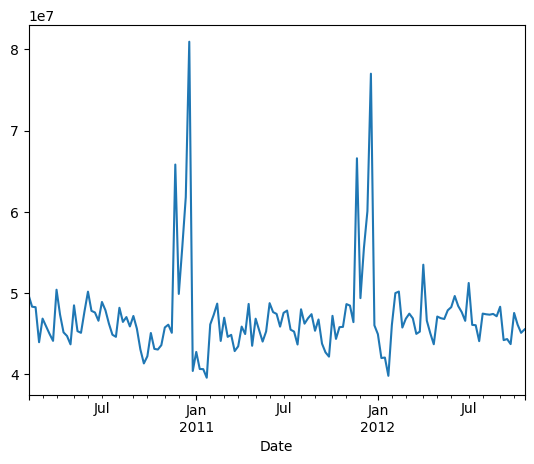

In [ ]:
weekly_trend = df.groupby("Date")["Weekly_Sales"].sum()
weekly_trend.plot()


In [ ]:
df[["Weekly_Sales", "Temperature"]].corr()

,Weekly_Sales,Temperature
Weekly_Sales,1.00000,-0.06381
Temperature,-0.06381,1.00000


<Axes: xlabel='Date'>

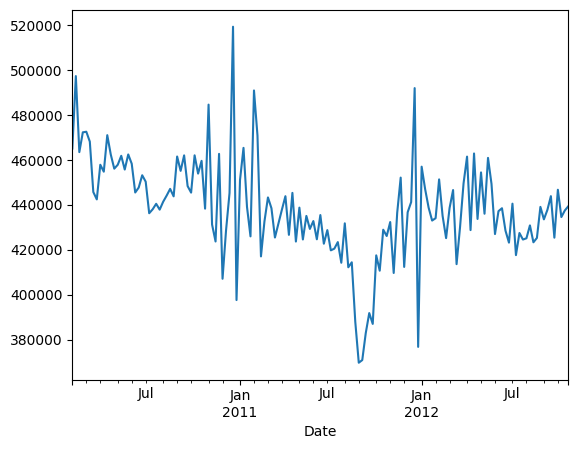

In [ ]:
store_30 = df[df["Store"] == 30]
store_30.set_index("Date")["Weekly_Sales"].plot()


In [ ]:
df[["Weekly_Sales", "CPI", "Unemployment"]].corr()

,Weekly_Sales,CPI,Unemployment
Weekly_Sales,1.000000,-0.072634,-0.106176
CPI,-0.072634,1.000000,-0.302020
Unemployment,-0.106176,-0.302020,1.000000


In [ ]:
df["Weekly_Sales"].describe()

,Weekly_Sales
count,6.435000e+03
mean,1.046965e+06
std,5.643666e+05
min,2.099862e+05
25%,5.533501e+05
50%,9.607460e+05
75%,1.420159e+06
max,3.818686e+06


In [ ]:
holiday_df = df[df["Holiday_Flag"] == 1]
holiday_df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending = False).head


<bound method NDFrame.head of Store
20    2249035.081
4     2243102.624
14    2120582.998
10    2113755.949
13    2113043.806
2     2079266.900
27    1892299.278
6     1680907.927
1     1665747.656
19    1577046.734
39    1551127.480
31    1500026.030
28    1478244.605
24    1475098.251
23    1462542.294
11    1448394.485
41    1334947.856
32    1203784.083
18    1169422.161
12    1138140.420
22    1084874.656
35    1074348.457
26    1072046.849
34    1041978.089
40    1008034.075
17     979796.971
8      975330.860
45     836293.713
21     826491.309
25     739676.842
15     706406.018
7      672400.265
43     635946.278
29     606957.889
9      588950.821
42     567694.158
16     566733.646
37     507525.050
3      437811.050
30     436859.307
38     381509.878
36     367640.630
5      359501.607
44     296035.601
33     262594.519
Name: Weekly_Sales, dtype: float64>

<Axes: xlabel='Date'>

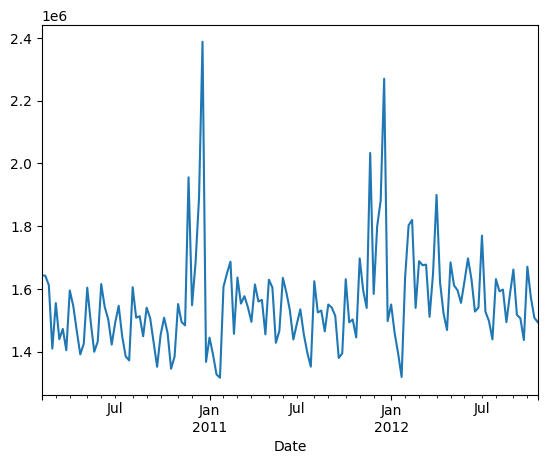

In [ ]:
store_1 = df[df["Store"] == 1]
store_1.set_index("Date")["Weekly_Sales"].plot()
